# The history estimators of adaptive data rate, as baselines

The history inputs of notebooks 12 to 17 are not new as an idea: adaptive data rate schemes already estimate a link from its recent packets, and the literature offers several estimators, a moving average, a median, an exponential average, a Kalman filter, a linear regression over the last packets, and the standard rule that uses the best of the last 20 packets. This notebook puts them on the same footing as the learned models.

* Every estimator gives a causal prediction `p` of the current path loss from earlier packets of the same link. The margin above the anchor is `p - a + c`, with the shift `c` calibrated on the validation folds exactly as in notebook 17.
* Two calibrations are shown: one shift per group (spreading factor x working hours), which needs no feedback, and adaptive conformal inference per link, which uses the observed misses.
* The tuned estimators (exponential average, Kalman filter) are tuned on the validation folds only. All scores are on the hold-out, with 95 % intervals from resampling days.
* The learned models are the LightGBM and the GRU on rung H4, read from their saved predictions.
* A reference row shows the standard rule without calibration: the best of the last 20 packets plus a fixed 10 dB.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from history_features import RUNGS
from margin_tools import pinball, shift_pooled, shift_groups, aci, day_codes, boot_stat, transitions, clustering_ratio

TAU = 0.99

In [2]:
# The rows and folds of notebooks 13 to 17
train = pd.read_csv("Data_Files/history_train.csv")
test = pd.read_csv("Data_Files/history_test.csv")
d = pd.concat([train, test], ignore_index=True)
d["t"] = pd.to_datetime(d["t"], utc=True)
d = d.sort_values("t").reset_index(drop=True)
fold = d["fold"].to_numpy()
H = {k.split()[0]: v for k, v in RUNGS.items()}
ok = (d["y"].notna() & d[H["H7"]].notna().all(axis=1)).to_numpy()
PL, a, y = d["PL"].to_numpy(), d["a"].to_numpy(), d["y"].to_numpy()
link, sf, work = d["device_id"].to_numpy(), d["SF"].to_numpy().astype(int), d["work"].to_numpy().astype(int)
day = day_codes(d["t"])
val, ev = ok & (fold >= 0) & (fold < 9), ok & (fold == 9)
g = d.groupby("device_id", sort=False)["PL"]
print(f"packets {len(d):,}; duplicated (link, time) pairs: {d.duplicated(['device_id', 't']).sum()}; validation {val.sum():,}; hold-out {ev.sum():,}")

packets 2,660,274; duplicated (link, time) pairs: 0; validation 1,773,285; hold-out 531,983


In [3]:
# Estimators of the current path loss from the link's earlier packets
est = {}
est["previous packet"] = g.shift(1).to_numpy()
est["mean of the last 20"] = g.transform(lambda s: s.shift(1).rolling(20, min_periods=10).mean()).to_numpy()
est["median of the last 20"] = g.transform(lambda s: s.shift(1).rolling(20, min_periods=10).median()).to_numpy()
est["best of the last 20"] = g.transform(lambda s: s.shift(1).rolling(20, min_periods=10).min()).to_numpy()     # lowest path loss = highest SNR, the standard rule
est["previous hour mean"] = a
est["24 hour mean"] = a + d["r_m24h"].to_numpy()

def linear_extrapolation(s, n=20):
    """Least-squares line through the last n packets, extended by one step (the linear-regression scheme)."""
    v = s.to_numpy()
    mean = s.shift(1).rolling(n, min_periods=n).mean().to_numpy()
    weighted = np.convolve(v, np.arange(n + 1))[: len(v)]               # sum over k of k * v[t - k]
    slope = (-weighted + n * (n + 1) / 2 * mean) / (n * (n * n - 1) / 12)
    return pd.Series(mean + slope * (n + 1) / 2, index=s.index)
est["linear regression over the last 20"] = g.transform(linear_extrapolation).to_numpy()

rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
alphas = (0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5)
ema = {al: g.transform(lambda s: s.shift(1).ewm(alpha=al, adjust=False).mean()).to_numpy() for al in alphas}
scores = {al: rmse((PL - ema[al])[val & np.isfinite(ema[al])]) for al in alphas}
alpha = min(scores, key=scores.get)
est[f"exponential average, weight {alpha}"] = ema[alpha]
print("exponential average, validation RMSE by weight:", {k: round(v, 3) for k, v in scores.items()})

exponential average, validation RMSE by weight: {0.005: 3.646, 0.01: 3.537, 0.02: 3.463, 0.05: 3.416, 0.1: 3.415, 0.2: 3.437, 0.5: 3.596}


In [4]:
# Kalman filter for a drifting level: the level moves by a random step whose variance grows with the minutes since the last packet
def kalman(pl, minutes, q, r=1.0):
    pred = np.full(len(pl), np.nan)
    x, p = pl[0], r
    for i in range(1, len(pl)):
        p += q * minutes[i]
        pred[i] = x
        gain = p / (p + r)
        x += gain * (pl[i] - x)
        p *= 1 - gain
    return pred

minutes = g.transform(lambda s: d.loc[s.index, "t"].diff().dt.total_seconds() / 60).to_numpy()
kal = {}
for q in (1e-4, 1e-3, 1e-2, 1e-1):
    p = np.full(len(d), np.nan)
    for l in np.unique(link):
        i = np.flatnonzero(link == l)
        p[i] = kalman(PL[i], minutes[i], q)
    kal[q] = p
scores = {q: rmse((PL - kal[q])[val & np.isfinite(kal[q])]) for q in kal}
q_best = min(scores, key=scores.get)
est[f"Kalman filter, drift {q_best}"] = kal[q_best]
print("Kalman filter, validation RMSE by drift variance per minute (measurement variance 1):", {k: round(v, 3) for k, v in scores.items()})

Kalman filter, validation RMSE by drift variance per minute (measurement variance 1): {0.0001: 3.525, 0.001: 3.429, 0.01: 3.417, 0.1: 3.474}


In [5]:
# The learned models, from their saved predictions on rung H4 (validation folds out of fold, hold-out from the final fit)
position = pd.Series(np.arange(len(d)), index=pd.MultiIndex.from_arrays([d["device_id"], d["t"]]))
def saved(model):
    p = np.full(len(d), np.nan)
    for split in ("oof", "test"):
        r = pd.read_csv(f"Residuals/residuals_{model}_{split}.csv", usecols=["time", "device_id", "PL_pred"])
        i = position.reindex(pd.MultiIndex.from_arrays([r["device_id"], pd.to_datetime(r["time"], utc=True)])).to_numpy()
        found = ~np.isnan(i)
        p[i[found].astype(int)] = r["PL_pred"].to_numpy()[found]
    return p
est["LightGBM on rung H4"] = saved("LGBM_H4")
est["GRU on rung H4"] = saved("GRU_H4")

common = ok & np.all([np.isfinite(p) for p in est.values()], axis=0)
val_c, ev_c = val & common, ev & common
print(f"{len(est)} estimators; rows common to all: validation {val_c.sum():,}, hold-out {ev_c.sum():,}")

11 estimators; rows common to all: validation 1,773,285, hold-out 531,983


In [6]:
# Margins on the hold-out: the shift comes from the validation folds; coverage, margin above the anchor and pinball loss at 99 %
te, cal = np.flatnonzero(ev_c), np.flatnonzero(val_c)
g1_cal, g1_te = (sf[cal] - 7) * 2 + work[cal], (sf[te] - 7) * 2 + work[te]
dd = pd.factorize(day[te])[0]
rows, margin = [], {}
for name, p in est.items():
    b = p - a                                                    # threshold above the anchor before the shift
    score = PL[cal] - p[cal]
    m = {"SF x hours": b[te] + shift_groups(score, g1_cal, g1_te, TAU)}
    m["ACI"] = np.empty(len(te))
    for l in np.unique(link[te]):
        i = np.flatnonzero(link[te] == l)
        m["ACI"][i] = aci(b[te][i], y[te][i], score, TAU, (1 - TAU) / 20)
    for how, mm in m.items():
        margin[(name, how)] = mm
        miss = (y[te] > mm).astype(float)
        loss = pinball(y[te], mm, TAU)
        ratio = clustering_ratio(transitions(d["t"].iloc[te], link[te], miss).sum(0, keepdims=True))[0]
        rows.append(dict(estimator=name, calibration=how, rmse=rmse(PL[te] - p[te]), coverage=1 - miss.mean(), margin=mm.mean(), pinball=loss.mean() * 1000, miss_clustering=ratio))
result = pd.DataFrame(rows)
reference = "LightGBM on rung H4"
lo_hi = []
for name, how in margin:
    diff = pinball(y[te], margin[(name, how)], TAU) - pinball(y[te], margin[(reference, how)], TAU)
    lo_hi.append(boot_stat(dd, np.column_stack([diff, np.ones(len(te))]), lambda T: 1000 * T[:, 0] / T[:, 1]))
result[["pinball_minus_lightgbm", "lo", "hi"]] = lo_hi
rmse_ci = {name: boot_stat(dd, np.column_stack([np.square(PL[te] - p[te]), np.ones(len(te))]), lambda T: np.sqrt(T[:, 0] / T[:, 1])) for name, p in est.items()}
result[["rmse_lo", "rmse_hi"]] = [rmse_ci[n][1:] for n in result.estimator]
result.to_csv("CV_Results/adr_estimators.csv", index=False)
order = result[result.calibration == "SF x hours"].sort_values("rmse").estimator.tolist()
print("hold-out, by estimator: RMSE of the level estimate and, per calibration, coverage, mean margin above the anchor, pinball loss x 1000 and its difference to LightGBM")
display(result.set_index(["estimator", "calibration"]).loc[[(n, c) for n in order for c in ("SF x hours", "ACI")]].round(3))

hold-out, by estimator: RMSE of the level estimate and, per calibration, coverage, mean margin above the anchor, pinball loss x 1000 and its difference to LightGBM


rmse  coverage  margin  \
estimator                          calibration                            
LightGBM on rung H4                SF x hours   1.950     0.993   5.028   
                                   ACI          1.950     0.990   4.789   
GRU on rung H4                     SF x hours   1.969     0.993   4.951   
                                   ACI          1.969     0.990   4.913   
exponential average, weight 0.1    SF x hours   2.625     0.994   5.689   
                                   ACI          2.625     0.990   6.779   
Kalman filter, drift 0.01          SF x hours   2.626     0.994   5.690   
                                   ACI          2.626     0.990   6.789   
mean of the last 20                SF x hours   2.632     0.995   5.927   
                                   ACI          2.632     0.990   6.928   
median of the last 20              SF x hours   2.691     0.995   6.213   
                                   ACI          2.691     0.990   7.040   
previous hour mean                 SF x hours   2.712     0.994   6.042   
                                   ACI          2.712     0.990   7.178   
linear regression over the last 20 SF x hours   3.033     0.991   6.146   
                                   ACI          3.033     0.990   7.388   
previous packet                    SF x hours   3.044     0.991   6.795   
                                   ACI          3.044     0.991   7.184   
24 hour mean                       SF x hours   3.294     0.993   8.866   
                                   ACI          3.294     0.991   8.386   
best of the last 20                SF x hours   5.055     0.997   9.538   
                                   ACI          5.055     0.991   8.255   

                                                pinball  miss_clustering  \
estimator                          calibration                             
LightGBM on rung H4                SF x hours    65.339           10.164   
                                   ACI           66.797            6.932   
GRU on rung H4                     SF x hours    65.643            8.202   
                                   ACI           68.072            5.698   
exponential average, weight 0.1    SF x hours    70.886           18.499   
                                   ACI           85.462            6.422   
Kalman filter, drift 0.01          SF x hours    70.971           18.428   
                                   ACI           85.586            6.699   
mean of the last 20                SF x hours    72.637           26.685   
                                   ACI           87.383            9.769   
median of the last 20              SF x hours    75.639           35.532   
                                   ACI           89.252           12.072   
previous hour mean                 SF x hours    76.399           32.180   
                                   ACI           91.300           15.053   
linear regression over the last 20 SF x hours    77.380            9.492   
                                   ACI           91.206            5.473   
previous packet                    SF x hours    85.195            0.445   
                                   ACI           89.146            0.254   
24 hour mean                       SF x hours   111.365          129.345   
                                   ACI          105.835           29.246   
best of the last 20                SF x hours   106.535          170.687   
                                   ACI          103.843           31.886   

                                                pinball_minus_lightgbm  \
estimator                          calibration                           
LightGBM on rung H4                SF x hours                    0.000   
                                   ACI                           0.000   
GRU on rung H4                     SF x hours                    0.304   
                                   ACI               

In [7]:
# The standard rule without calibration: the best of the last 20 packets plus a fixed margin
fixed = 10.0
m = (est["best of the last 20"] - a)[te] + fixed
miss = y[te] > m
print(f"best of the last 20 packets plus a fixed {fixed:.0f} dB: coverage {1 - miss.mean():.4f} (target {TAU}), mean margin above the anchor {m.mean():.2f} dB, pinball loss x 1000 {pinball(y[te], m, TAU).mean() * 1000:.1f}")
m = (est["mean of the last 20"] - a)[te] + fixed
print(f"mean of the last 20 packets plus a fixed {fixed:.0f} dB: coverage {1 - (y[te] > m).mean():.4f}, mean margin above the anchor {m.mean():.2f} dB")

best of the last 20 packets plus a fixed 10 dB: coverage 0.9669 (target 0.99), mean margin above the anchor 5.90 dB, pinball loss x 1000 128.0
mean of the last 20 packets plus a fixed 10 dB: coverage 0.9986, mean margin above the anchor 10.00 dB


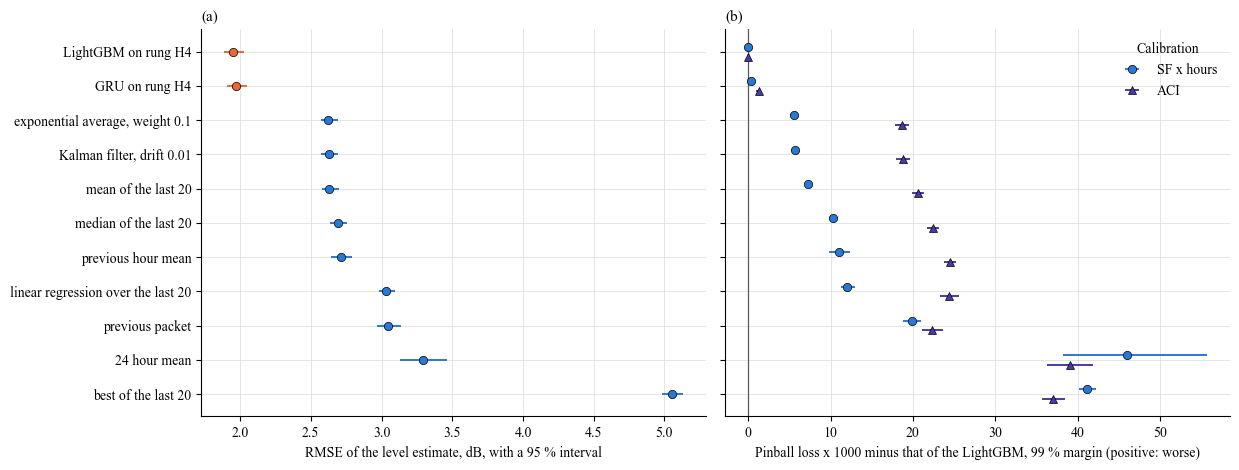

In [8]:
# Figure: the estimators on the hold-out
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"], "font.size": 10})
classic = [n for n in order if n not in ("LightGBM on rung H4", "GRU on rung H4")]
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
pos = {n: len(order) - 1 - i for i, n in enumerate(order)}
for n in order:
    r = result[(result.estimator == n) & (result.calibration == "SF x hours")].iloc[0]
    learned = n not in classic
    ax[0].errorbar(r.rmse, pos[n], xerr=[[r.rmse - r.rmse_lo], [r.rmse_hi - r.rmse]], fmt="o", color="#eb6834" if learned else "#2a78d6", ms=6, mec="black", mew=0.5, lw=1.4)
for how, colour, marker, shift in (("SF x hours", "#2a78d6", "o", 0.14), ("ACI", "#4a3aa7", "^", -0.14)):
    for n in order:
        r = result[(result.estimator == n) & (result.calibration == how)].iloc[0]
        ax[1].errorbar(r.pinball_minus_lightgbm, pos[n] + shift, xerr=[[r.pinball_minus_lightgbm - r.lo], [r.hi - r.pinball_minus_lightgbm]], fmt=marker, color=colour, ms=6, mec="black", mew=0.5, lw=1.4,
                       label=how if n == order[0] else None)
ax[0].set_yticks(list(pos.values()), list(pos.keys()))
ax[0].set_xlabel("RMSE of the level estimate, dB, with a 95 % interval")
ax[1].set_xlabel("Pinball loss x 1000 minus that of the LightGBM, 99 % margin (positive: worse)")
ax[1].axvline(0, color="0.35", lw=0.9)
ax[1].legend(frameon=False, loc="upper right", title="Calibration")
for a_, tag in zip(ax, "ab"):
    a_.grid(color="0.88", lw=0.6)
    a_.set_axisbelow(True)
    a_.set_title(f"({tag})", loc="left", fontsize=11)
    for sp in ("top", "right"):
        a_.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig("Figures/adr_estimators.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading of the results.**

* **The learned history models beat every estimator of the adaptive data rate literature.** On the hold-out the best classical ones, the exponential average and the Kalman filter, reach 2.63 dB, level with the mean of the last 20 packets and the previous-hour mean. LightGBM on rung H4 reaches 1.95 dB and the GRU 1.97 dB. In pinball loss the exponential average is 5.5 points above the LightGBM per thousand, with a 95 % interval from 5.1 to 6.0.
* **Filtering is not what matters.** The classical estimators lie within 0.1 dB of each other from the mean of 20 packets to the Kalman filter. The learned models gain from inputs the classical ones do not use: the longer windows and the quantiles of the link's history in rung H1, and the same-channel history, the clock and the spreading factor in rung H4.
* **The standard rule is the weakest.** The best of the last 20 packets selects the extreme and estimates the level with 5.1 dB RMSE. A fixed 10 dB above it reaches 96.7 % coverage at a 99 % target, at a mean margin of 5.9 dB above the anchor. The same 10 dB above the mean of the last 20 packets reaches 99.9 %.
* **Calibration.** A shift per group of spreading factor and working hours is sharper than adaptive conformal inference with pooled scores for every estimator except the two weakest, the 24-hour mean and the best of the last 20 packets. The adaptive calibration brings the coverage to the target and cuts the clustering of the misses by a third or more.
* **The GRU** is level with the LightGBM: 0.3 points per thousand above it in pinball loss with the group calibration, with an interval from 0.03 to 0.60.